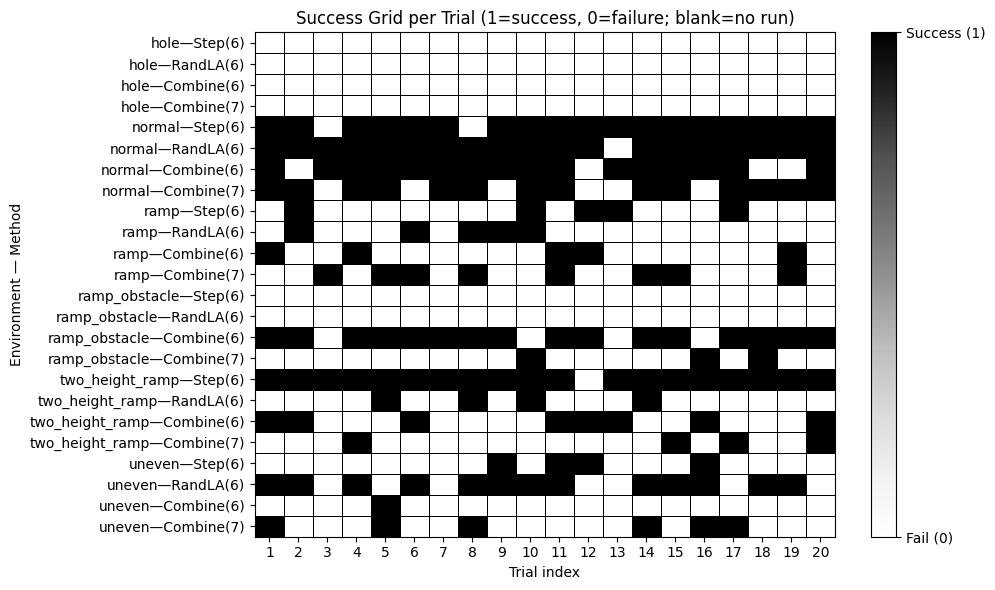

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict
with open('../record/finalstep_stats_3.json') as f:
    data = json.load(f)
with open('../record/finalrandla_stats_3.json') as f2:
    data2 = json.load(f2)
with open('../record/finalstepmean_stats_3.json') as f3:
    data3 = json.load(f3)
with open('../record/finalmax_stats_3.json') as f4:
    data4 = json.load(f4)
with open('../record/finalmean_stats_3.json') as f5:
    data5 = json.load(f5)
with open('../record/finalcombine_stats_3.json') as f6:
    data6 = json.load(f6)

# Map env names
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    # Add these new hole variations
    ((-55, -13), (-41, -13)): "hole",
    ((-53, -13), (-41, -13)): "hole",
    ((-53, -14), (-41, -13)): "hole",
    ((-54, -13), (-41, -13)): "hole",
}

def env_label_for(entry):
    # Ensure these match the dictionary keys exactly
    start = tuple(round(x) for x in entry["start_point"])
    goal  = tuple(round(x) for x in entry["goal_point"])
    
    # Check if the tuple exists in our map
    label = env_map.get((start, goal))
    
    # If not found, we return the raw string so we can debug it
    return label if label else f"{start}→{goal}"

# 2. Ensure data is actually being captured
def success_vectors(raw_entries):
    by_env = defaultdict(list)
    for e in raw_entries:
        lbl = env_label_for(e)
        # Only append if 'reach_goal' key exists to avoid key errors
        val = 1 if e.get("reach_goal") == True else 0
        by_env[lbl].append(val)
    return by_env

step6   = success_vectors(data)
randla6 = success_vectors(data2)
comb6   = success_vectors(data3)
comb7   = success_vectors(data4)

# Unified set of environments, sorted for stable row order
all_envs = sorted(set(step6) | set(randla6) | set(comb6) | set(comb7))

# Row labels in your requested style per environment
methods = [
    ("Step(6)",   step6),
    ("RandLA(6)", randla6),
    ("Combine(6)",comb6),
    ("Combine(7)",comb7),
]

row_labels = []
rows = []

for env in all_envs:
    for mname, mdict in methods:
        row_labels.append(f"{env}—{mname}")
        rows.append(mdict.get(env, []))

# Determine width (max trials across all rows) and build a padded matrix
max_len = max((len(r) for r in rows), default=0)
grid = np.full((len(rows), max_len), np.nan)  # NaN will render as blank

for i, r in enumerate(rows):
    if len(r) > 0:
        grid[i, :len(r)] = r  # fill with 0/1

# Plot as a crisp grid 
fig, ax = plt.subplots(figsize=(max(10, max_len*0.35), max(6, len(rows)*0.25)))

# Use pcolormesh so we can draw cell borders easily
c = ax.pcolormesh(
    np.arange(max_len+1), np.arange(len(rows)+1),
    np.flipud(grid),  # flip vertically to have first row at top
    shading='flat', edgecolors='black', linewidth=0.4,
    cmap='Greys', vmin=0, vmax=1
)

# Ticks: trials on x, row labels on y
ax.set_xticks(np.arange(max_len) + 0.5)
ax.set_xticklabels([str(i+1) for i in range(max_len)], rotation=0)
ax.set_xlabel("Trial index")

ax.set_yticks(np.arange(len(rows)) + 0.5)
ax.set_yticklabels(list(reversed(row_labels))) 
ax.set_ylabel("Environment — Method")

ax.set_title("Success Grid per Trial (1=success, 0=failure; blank=no run)")
cb = fig.colorbar(c, ax=ax, ticks=[0, 1])
cb.ax.set_yticklabels(['Fail (0)', 'Success (1)'])

plt.tight_layout()
plt.show()


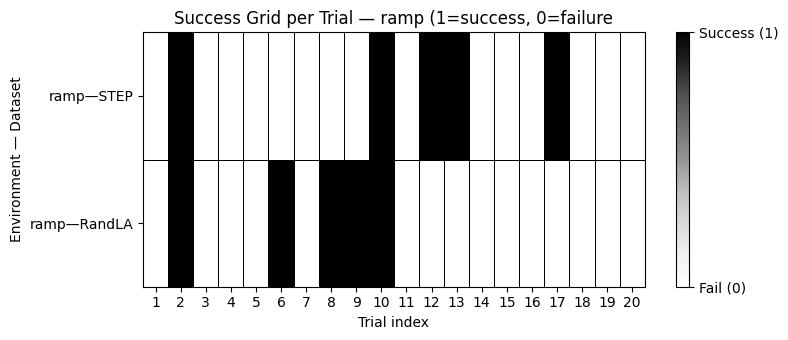

In [8]:

# Compute success vectors for the two files
v9  = success_vectors(data)
v10 = success_vectors(data2)

target_envs = [e for e in set(v9) | set(v10) if e.lower() == "ramp"]

if not target_envs:
    # Fall back to any env label that contains 'ramp' (e.g., "two_height_ramp"), if strict 'ramp' is absent
    target_envs = [e for e in set(v9) | set(v10) if "ramp" in e.lower()]

if not target_envs:
    raise ValueError("No 'ramp' environment found in the provided files.")

# Prepare rows for plotting
methods = [
    ("STEP",  v9),
    ("RandLA", v10),
]

row_labels = []
rows = []

for env in target_envs:  # typically just
    for mname, mdict in methods:
        row_labels.append(f"{env}—{mname}")
        rows.append(mdict.get(env, []))

# Determine width (max trials across all rows) and build a padded matrix
max_len = max((len(r) for r in rows), default=0)
grid = np.full((len(rows), max_len), np.nan)  # NaN will render as blank

for i, r in enumerate(rows):
    if len(r) > 0:
        grid[i, :len(r)] = r  # fill with 0/1

# Plot as a crisp grid
fig, ax = plt.subplots(figsize=(max(8, max_len*0.35), max(3.5, len(rows)*0.5)))

c = ax.pcolormesh(
    np.arange(max_len+1), np.arange(len(rows)+1),
    np.flipud(grid),  # flip vertically to have first row at top
    shading='flat', edgecolors='black', linewidth=0.4,
    cmap='Greys', vmin=0, vmax=1
)

# Ticks: trials on x, row labels on y
ax.set_xticks(np.arange(max_len) + 0.5)
ax.set_xticklabels([str(i+1) for i in range(max_len)], rotation=0)
ax.set_xlabel("Trial index")

ax.set_yticks(np.arange(len(rows)) + 0.5)
ax.set_yticklabels(list(reversed(row_labels))) 
ax.set_ylabel("Environment — Dataset")

title_env = ", ".join(target_envs)
ax.set_title(f"Success Grid per Trial — {title_env} (1=success, 0=failure")

cb = fig.colorbar(c, ax=ax, ticks=[0, 1])
cb.ax.set_yticklabels(['Fail (0)', 'Success (1)'])

plt.tight_layout()
plt.show()


## Others


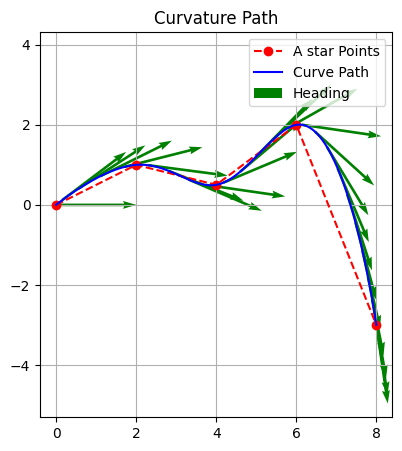

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

def arc_length_parametrize(P, ds=0.1):
    seg = np.diff(P, axis=0)
    s   = np.concatenate([[0.0], np.cumsum(np.linalg.norm(seg, axis=1))])
    S   = np.arange(0, s[-1]+1e-9, ds)
    sx = CubicSpline(s, P[:,0], bc_type='clamped')
    sy = CubicSpline(s, P[:,1], bc_type='clamped')
    X  = np.column_stack([sx(S), sy(S)])
    dx, dy   = sx(S, 1), sy(S, 1)
    ddx, ddy = sx(S, 2), sy(S, 2)
    psi      = np.arctan2(dy, dx)
    kappa    = (dx*ddy - dy*ddx) / np.maximum((dx*dx + dy*dy)**1.5, 1e-6)
    return X, psi, kappa, S

# Example path (some random control points)
P = np.array([[0,0], [2,1], [4,0.5], [6,2], [8,-3]])

X, psi, kappa, S = arc_length_parametrize(P, ds=0.05)

# Plot path and heading
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(P[:,0], P[:,1], 'ro--', label='A star Points')
plt.plot(X[:,0], X[:,1], 'b-', label='Curve Path')
plt.quiver(X[::10,0], X[::10,1], np.cos(psi[::10]), np.sin(psi[::10]), 
           angles='xy', scale_units='xy', scale=0.5, color='g', label='Heading')
plt.title('Curvature Path')
plt.axis('equal')
plt.legend()
plt.grid(True)

<>:55: SyntaxWarning: invalid escape sequence '\k'
<>:57: SyntaxWarning: invalid escape sequence '\k'
<>:55: SyntaxWarning: invalid escape sequence '\k'
<>:57: SyntaxWarning: invalid escape sequence '\k'
C:\Users\gavin\AppData\Local\Temp\ipykernel_75860\1757113996.py:55: SyntaxWarning: invalid escape sequence '\k'
  ax2.set_title("Path Curvature ($\kappa$) vs. Arc Length")
C:\Users\gavin\AppData\Local\Temp\ipykernel_75860\1757113996.py:57: SyntaxWarning: invalid escape sequence '\k'
  ax2.set_ylabel("Curvature ($\kappa$)")


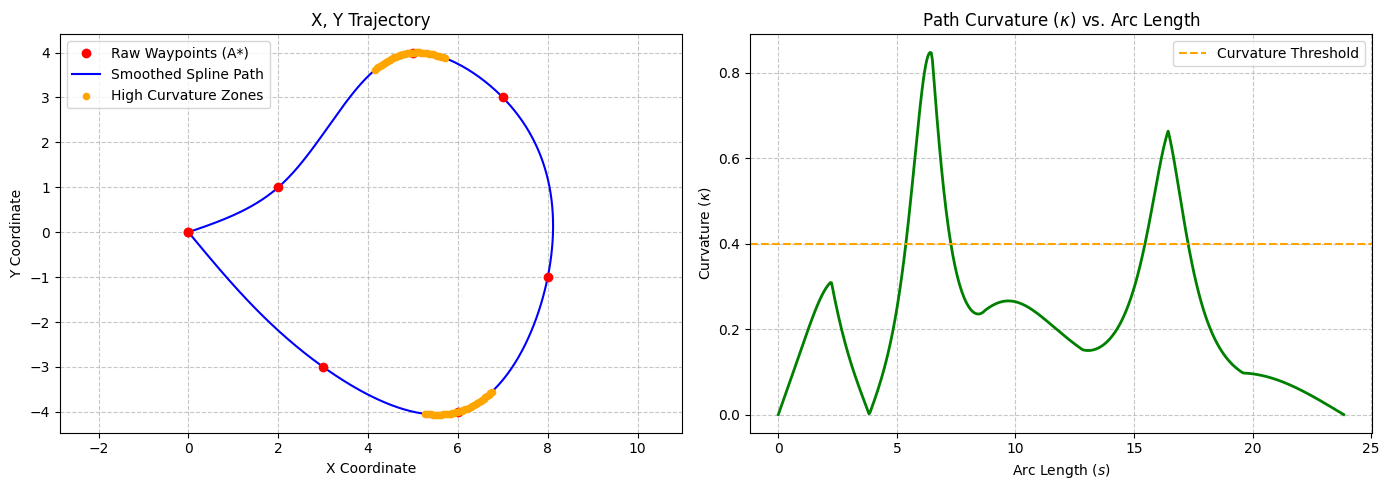

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

def plot_trajectory_and_curvature():
    # Generate some raw discrete waypoints (e.g., from A* planner)
    x_raw = np.array([0.0, 2.0, 5.0, 7.0, 8.0, 6.0, 3.0, 0.0])
    y_raw = np.array([0.0, 1.0, 4.0, 3.0, -1.0, -4.0, -3.0, 0.0])

    # Approximate arc length (s) to use as the parameter for the spline
    distances = np.sqrt(np.diff(x_raw)**2 + np.diff(y_raw)**2)
    s_raw = np.zeros(len(x_raw))
    s_raw[1:] = np.cumsum(distances)

    # Fit Cubic Splines for x(s) and y(s)
    cs_x = CubicSpline(s_raw, x_raw, bc_type='natural')
    cs_y = CubicSpline(s_raw, y_raw, bc_type='natural')

    # Generate a finely interpolated path for smooth control/plotting
    s_fine = np.linspace(s_raw[0], s_raw[-1], 500)
    x_fine = cs_x(s_fine)
    y_fine = cs_y(s_fine)

    # Compute first and second derivatives with respect to s
    dx = cs_x(s_fine, 1)
    dy = cs_y(s_fine, 1)
    ddx = cs_x(s_fine, 2)
    ddy = cs_y(s_fine, 2)

    # Calculate curvature (kappa)
    curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5

    # Plotting the results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Spatial Trajectory
    ax1.plot(x_raw, y_raw, 'ro', label='Raw Waypoints (A*)', zorder=3)
    ax1.plot(x_fine, y_fine, 'b-', label='Smoothed Spline Path', zorder=2)
    
    # Highlight points of high curvature on the spatial plot
    high_curv_idx = np.where(curvature > 0.4)[0]
    ax1.scatter(x_fine[high_curv_idx], y_fine[high_curv_idx], color='orange', 
                s=20, label='High Curvature Zones', zorder=4)

    ax1.set_title("X, Y Trajectory")
    ax1.set_xlabel("X Coordinate")
    ax1.set_ylabel("Y Coordinate")
    ax1.axis('equal')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # plot Curvature vs Arc Length
    ax2.plot(s_fine, curvature, 'g-', linewidth=2)
    ax2.axhline(0.4, color='orange', linestyle='--', label='Curvature Threshold')
    ax2.set_title("Path Curvature ($\kappa$) vs. Arc Length")
    ax2.set_xlabel("Arc Length ($s$)")
    ax2.set_ylabel("Curvature ($\kappa$)")
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_trajectory_and_curvature()